In [1]:
import json
import urllib.request
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import Image, display
from scipy import stats


In [2]:
# Download data and build the clean daily BTC/USD dataset

RAW_URL = (
    "https://raw.githubusercontent.com/ff137/"
    "bitstamp-btcusd-minute-data/refs/heads/main/"
    "data/historical/btcusd_bitstamp_1min_2012-2025.csv.gz"
)
ANALYSIS_START = "2015-01-10"
TRAIN_START, TRAIN_END = "2015-01-10", "2019-12-31"
VALIDATION_START, VALIDATION_END = "2020-01-01", "2021-12-31"
TEST_START, TEST_END = "2022-01-01", "2025-01-06"
PERIODS = {
    "train": (TRAIN_START, TRAIN_END),
    "validation": (VALIDATION_START, VALIDATION_END),
    "test": (TEST_START, TEST_END),
    "full": (ANALYSIS_START, TEST_END),
}
HORIZONS = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60, 90, 120]
CANDIDATE_HORIZONS = [5, 10, 15, 20, 30, 45, 60, 90]
MARKET_ORDER_COST = 0.0020
LIMIT_ORDER_COST = 0.0007
ANNUALIZATION = 365

WORK_DIR = Path.cwd() / "notebook_runtime"
WORK_DIR.mkdir(exist_ok=True)
FIGURES_DIR = WORK_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
RAW_PATH = WORK_DIR / "btcusd_bitstamp_1min_2012-2025.csv.gz"
DAILY_PATH = WORK_DIR / "btc_daily.csv"

existing_sources = [
    Path.cwd() / "data" / "raw" / RAW_PATH.name,
    Path.cwd().parent / "data" / "raw" / RAW_PATH.name,
    RAW_PATH,
]
source = next((path for path in existing_sources if path.exists()), None)
if source is None:
    print("Downloading BTC/USD minute data. This is about 95 MB compressed.")
    urllib.request.urlretrieve(RAW_URL, RAW_PATH)
    source = RAW_PATH
else:
    print(f"Using raw data source: {source}")

if not DAILY_PATH.exists():
    raw = pd.read_csv(source, compression="gzip")
    raw["timestamp"] = pd.to_datetime(raw["timestamp"], unit="s", utc=True)
    raw = raw.set_index("timestamp").sort_index()
    if raw.index.has_duplicates:
        raise ValueError("Raw data contains duplicate timestamps.")
    if raw[["open", "high", "low", "close", "volume"]].isna().any().any():
        raise ValueError("Raw data contains missing OHLCV values.")

    daily_all = raw.resample("1D").agg(
        open=("open", "first"),
        high=("high", "max"),
        low=("low", "min"),
        close=("close", "last"),
        volume=("volume", "sum"),
        minute_count=("close", "size"),
    )
    daily_clean = daily_all[
        (daily_all["minute_count"] == 1440) & (daily_all["volume"] > 0)
    ].drop(columns="minute_count")
    daily_clean.index.name = "timestamp"
    daily_clean.to_csv(DAILY_PATH)
    print(f"Saved clean daily data: {DAILY_PATH}")

daily = pd.read_csv(DAILY_PATH, parse_dates=["timestamp"]).set_index("timestamp")
daily = daily.loc[ANALYSIS_START:TEST_END].copy()
daily["daily_return"] = daily["close"].pct_change()
print(f"Daily rows used for analysis: {len(daily):,}")
daily.head()


Using raw data source: /Users/anirudhnegi/Downloads/quant/quantproject/data/raw/btcusd_bitstamp_1min_2012-2025.csv.gz
Daily rows used for analysis: 3,650


,open,high,low,close,volume,daily_return
timestamp,,,,,,
2015-01-10 00:00:00+00:00,276.80,305.00,271.03,278.86,36858.985917,NaN
2015-01-11 00:00:00+00:00,278.86,280.94,270.70,271.00,10520.984308,-0.028186
2015-01-12 00:00:00+00:00,271.00,272.39,262.08,270.97,12942.806662,-0.000111
2015-01-13 00:00:00+00:00,270.98,272.43,216.00,232.55,47094.803471,-0.141787
2015-01-14 00:00:00+00:00,232.54,239.09,152.40,180.79,115814.462416,-0.222576


In [3]:
# Helper functions used by the full notebook backtest

def period_slice(series_or_frame, period):
    start, end = PERIODS[period]
    return series_or_frame.loc[start:end]

def period_labels(index):
    labels = pd.Series("outside", index=index, dtype="object")
    for period in ("train", "validation", "test"):
        start, end = PERIODS[period]
        labels.loc[start:end] = period
    return labels

def volume_zscore(volume, horizon):
    recent_average = volume.rolling(horizon, min_periods=horizon).mean()
    trailing_mean = volume.rolling(120, min_periods=120).mean()
    trailing_std = volume.rolling(120, min_periods=120).std()
    return (recent_average - trailing_mean) / trailing_std.replace(0, np.nan)

def strategy_returns(df, horizon, position_mode, activity_filter, execution_cost=MARKET_ORDER_COST):
    close = df["close"]
    volume = df["volume"]
    daily_return = close.pct_change()
    momentum = np.log(close / close.shift(horizon))

    if position_mode == "long_only":
        raw_position = (momentum > 0).astype(float)
    elif position_mode == "long_short":
        raw_position = np.sign(momentum).fillna(0.0)
    else:
        raise ValueError(position_mode)

    if activity_filter:
        vol_z = volume_zscore(volume, horizon)
        running_median = vol_z.expanding(min_periods=120).median()
        activity_ok = (vol_z > running_median).astype(float)
    else:
        activity_ok = pd.Series(1.0, index=df.index)

    position = (raw_position * activity_ok).shift(1).fillna(0.0)
    turnover = position.diff().abs().fillna(position.abs())
    cost = turnover * execution_cost
    net_return = position * daily_return - cost
    return pd.DataFrame({
        "position": position,
        "turnover": turnover,
        "gross_return": position * daily_return,
        "cost": cost,
        "net_return": net_return,
        "benchmark_return": daily_return,
    }).dropna()

def performance_stats(returns, benchmark=None):
    joined = pd.DataFrame({"returns": returns})
    if benchmark is not None:
        joined["benchmark"] = benchmark
    joined = joined.replace([np.inf, -np.inf], np.nan).dropna()
    rets = joined["returns"]
    wealth = (1.0 + rets).cumprod()
    total_return = wealth.iloc[-1] - 1.0
    cagr = (1.0 + total_return) ** (ANNUALIZATION / len(rets)) - 1.0
    annualized_mean = rets.mean() * ANNUALIZATION
    annualized_vol = rets.std(ddof=1) * np.sqrt(ANNUALIZATION)
    sharpe = rets.mean() / rets.std(ddof=1) * np.sqrt(ANNUALIZATION)
    drawdown = wealth / wealth.cummax() - 1.0
    result = {
        "n_obs": int(len(rets)),
        "total_return": float(total_return),
        "cagr": float(cagr),
        "annualized_mean_return": float(annualized_mean),
        "annualized_volatility": float(annualized_vol),
        "sharpe_ratio": float(sharpe),
        "max_drawdown": float(drawdown.min()),
        "alpha_annualized": np.nan,
        "alpha_p_hac": np.nan,
        "beta": np.nan,
        "r_squared": np.nan,
    }
    if benchmark is not None:
        x = sm.add_constant(joined["benchmark"])
        model = sm.OLS(rets, x).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
        result.update({
            "alpha_annualized": float(model.params.iloc[0] * ANNUALIZATION),
            "alpha_p_hac": float(model.pvalues.iloc[0]),
            "beta": float(model.params.iloc[1]),
            "r_squared": float(model.rsquared),
        })
    return result

def evaluate_period(name, model_name, returns, benchmark):
    return {
        "period": name,
        "model": model_name,
        **performance_stats(period_slice(returns, name), period_slice(benchmark, name)),
    }

def benchmark_period(name, benchmark):
    return {"period": name, "model": "btc_buy_hold", **performance_stats(period_slice(benchmark, name))}

BLUE = "#1F5A94"
GOLD = "#B07A16"
GRAY = "#8A939B"
RED = "#A33A3A"

def save_and_show(fig, filename):
    path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))


In [4]:
# Strategy #1: BTC Momentum Horizon Scan

rows = []
for horizon in HORIZONS:
    past_return = np.log(daily["close"] / daily["close"].shift(horizon))
    forward_return = np.log(daily["close"].shift(-horizon) / daily["close"])
    sample = pd.DataFrame({"past_return": past_return, "forward_return": forward_return})
    train = period_slice(sample, "train").dropna()
    pearson_r, pearson_p = stats.pearsonr(train["past_return"], train["forward_return"])
    model = sm.OLS(
        train["forward_return"],
        sm.add_constant(train["past_return"]),
    ).fit(cov_type="HAC", cov_kwds={"maxlags": horizon})
    rows.append({
        "period": "train",
        "horizon_days": horizon,
        "n_overlapping": len(train),
        "pearson_corr": pearson_r,
        "pearson_naive_p": pearson_p,
        "hac_slope": model.params.iloc[1],
        "hac_p": model.pvalues.iloc[1],
        "signal": "MOMENTUM" if pearson_r > 0 else "REVERSAL",
    })

horizon_scan = pd.DataFrame(rows)
horizon_scan


,period,horizon_days,n_overlapping,pearson_corr,pearson_naive_p,hac_slope,hac_p,signal
0,train,1,1816,-0.025975,2.685866e-01,-0.025971,0.541953,REVERSAL
1,train,2,1815,-0.027006,2.501697e-01,-0.026946,0.425789,REVERSAL
2,train,3,1814,0.016028,4.950848e-01,0.015784,0.672002,MOMENTUM
3,train,5,1812,0.040800,8.251732e-02,0.040379,0.391919,MOMENTUM
4,train,10,1807,0.063680,6.772559e-03,0.063240,0.333503,MOMENTUM
5,train,15,1802,0.093839,6.620555e-05,0.093799,0.248242,MOMENTUM
6,train,20,1797,0.045976,5.134035e-02,0.045954,0.548586,MOMENTUM
7,train,30,1787,0.024016,3.102738e-01,0.023990,0.786442,MOMENTUM
8,train,45,1772,0.107392,5.881586e-06,0.107608,0.386549,MOMENTUM
9,train,60,1757,0.131818,2.928492e-08,0.131950,0.350599,MOMENTUM


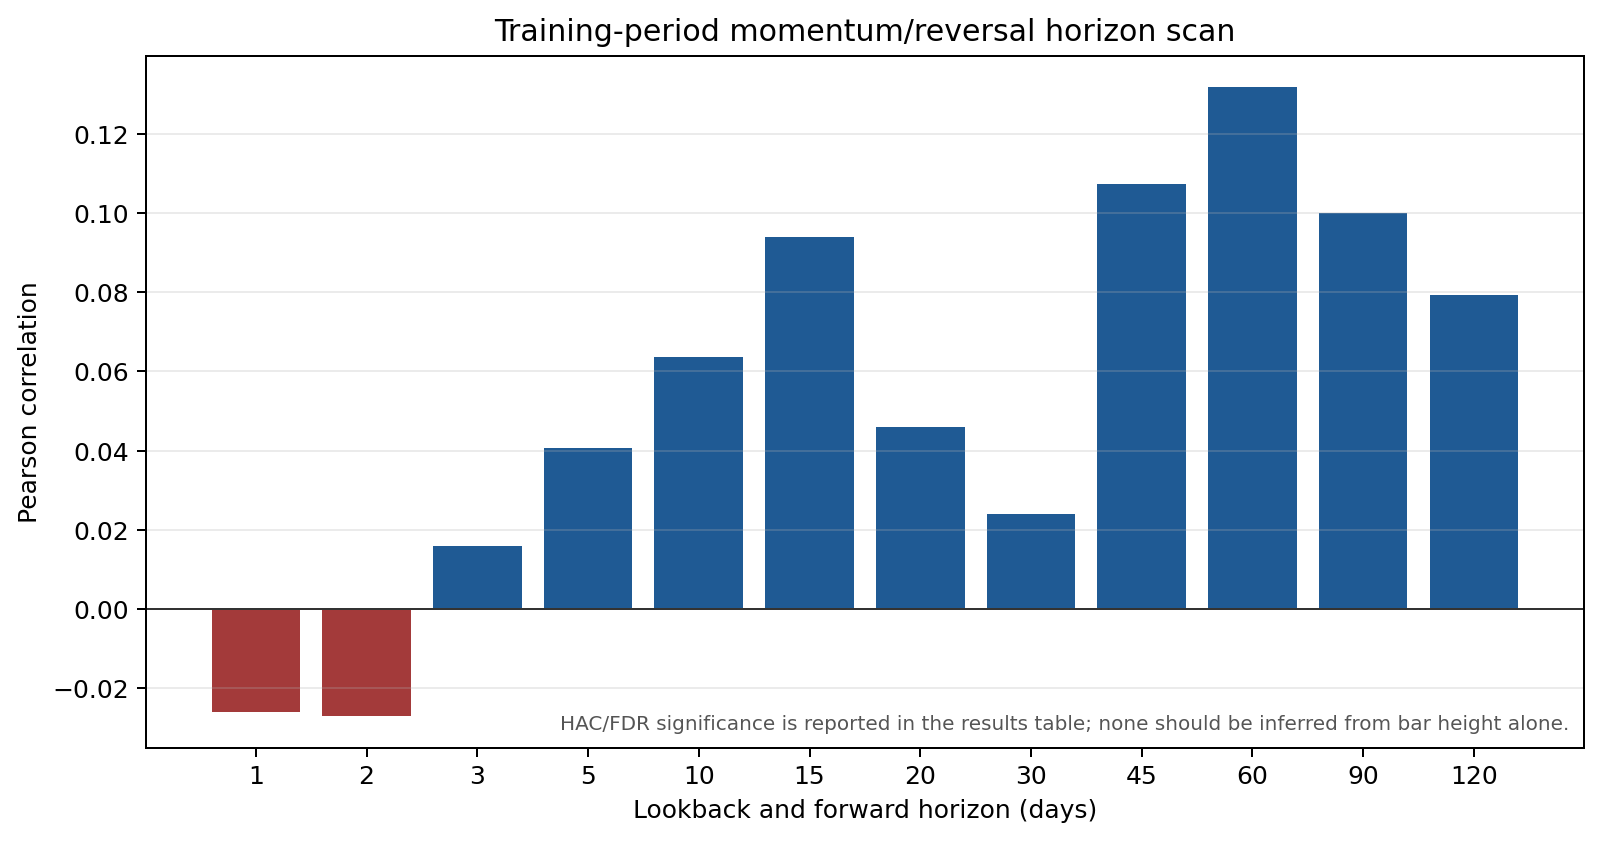

In [5]:
# Horizon scan chart

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = np.where(horizon_scan["pearson_corr"] >= 0, BLUE, RED)
ax.bar(horizon_scan["horizon_days"].astype(str), horizon_scan["pearson_corr"], color=colors)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_title("Training-period momentum/reversal horizon scan")
ax.set_xlabel("Lookback and forward horizon (days)")
ax.set_ylabel("Pearson correlation")
ax.grid(axis="y", alpha=0.25)
ax.text(
    0.99,
    0.02,
    "HAC/FDR significance is reported in the results table; none should be inferred from bar height alone.",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color="#555555",
)
save_and_show(fig, "horizon_scan.png")


In [6]:
# Strategy #2: Activity and Seasonality Checks

def correlation_row(analysis, group, sample, outcome_horizon_days):
    sample = sample.dropna()
    pearson_r, naive_p = stats.pearsonr(sample["signal"], sample["outcome"])
    model = sm.OLS(
        sample["outcome"],
        sm.add_constant(sample["signal"]),
    ).fit(cov_type="HAC", cov_kwds={"maxlags": max(1, outcome_horizon_days)})
    return {
        "analysis": analysis,
        "group": group,
        "signal_horizon_days": 20,
        "outcome_horizon_days": outcome_horizon_days,
        "n_obs": len(sample),
        "pearson_corr": pearson_r,
        "pearson_naive_p": naive_p,
        "hac_slope": model.params.iloc[1],
        "hac_p": model.pvalues.iloc[1],
        "mean_outcome_return": sample["outcome"].mean(),
    }

signal_20 = np.log(daily["close"] / daily["close"].shift(20))
forward_20 = np.log(daily["close"].shift(-20) / daily["close"])
vol_z = volume_zscore(daily["volume"], 20)
running_median = vol_z.expanding(min_periods=120).median()
activity = period_slice(
    pd.concat(
        {"signal": signal_20, "outcome": forward_20, "vol_z": vol_z, "threshold": running_median},
        axis=1,
    ),
    "train",
).dropna()

next_day_return = np.log(daily["close"].shift(-1) / daily["close"])
seasonality = period_slice(
    pd.concat({"signal": signal_20, "outcome": next_day_return}, axis=1),
    "train",
).dropna()
is_weekend = seasonality.index.dayofweek.isin([5, 6])

activity_results = pd.DataFrame([
    correlation_row("activity", "high_activity", activity[activity["vol_z"] > activity["threshold"]], 20),
    correlation_row("activity", "low_activity", activity[activity["vol_z"] <= activity["threshold"]], 20),
    correlation_row("entry_day_seasonality", "weekday", seasonality[~is_weekend], 1),
    correlation_row("entry_day_seasonality", "weekend", seasonality[is_weekend], 1),
])
activity_results


,analysis,group,signal_horizon_days,outcome_horizon_days,n_obs,pearson_corr,pearson_naive_p,hac_slope,hac_p,mean_outcome_return
0,activity,high_activity,20,20,761,-0.010368,0.775230,-0.009583,0.919657,0.075934
1,activity,low_activity,20,20,818,0.080557,0.021212,0.089902,0.412884,0.015845
2,entry_day_seasonality,weekday,20,1,1283,0.002299,0.934437,0.000509,0.954198,0.002018
3,entry_day_seasonality,weekend,20,1,514,0.152140,0.000538,0.030428,0.021383,0.001657


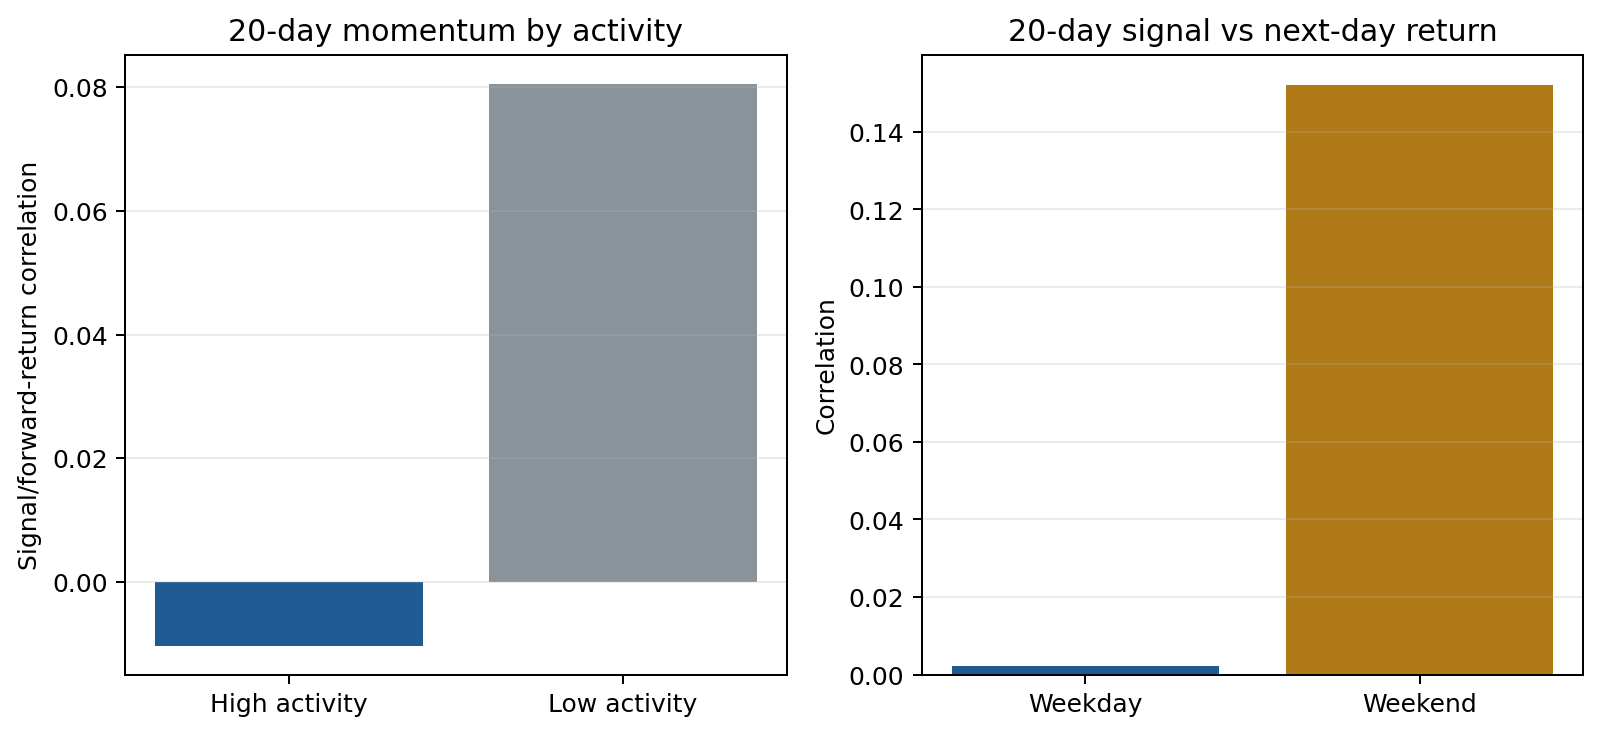

In [7]:
# Activity and seasonality chart

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
activity_subset = activity_results[activity_results["analysis"] == "activity"]
axes[0].bar(
    ["High activity", "Low activity"],
    activity_subset["pearson_corr"],
    color=[BLUE, GRAY],
)
axes[0].set_title("20-day momentum by activity")
axes[0].set_ylabel("Signal/forward-return correlation")
axes[0].grid(axis="y", alpha=0.25)

seasonality_subset = activity_results[activity_results["analysis"] == "entry_day_seasonality"]
axes[1].bar(
    ["Weekday", "Weekend"],
    seasonality_subset["pearson_corr"],
    color=[BLUE, GOLD],
)
axes[1].set_title("20-day signal vs next-day return")
axes[1].set_ylabel("Correlation")
axes[1].grid(axis="y", alpha=0.25)
save_and_show(fig, "activity_and_seasonality.png")


In [8]:
# Validation-based strategy selection and full backtest

selection_rows = []
for horizon in CANDIDATE_HORIZONS:
    for position_mode in ("long_only", "long_short"):
        for activity_filter in (False, True):
            bt = strategy_returns(
                daily,
                horizon=horizon,
                position_mode=position_mode,
                activity_filter=activity_filter,
            )
            validation = period_slice(bt, "validation")
            stats_row = performance_stats(validation["net_return"], validation["benchmark_return"])
            selection_rows.append({
                "horizon_days": horizon,
                "position_mode": position_mode,
                "activity_filter": activity_filter,
                "validation_sharpe": stats_row["sharpe_ratio"],
                "validation_cagr": stats_row["cagr"],
                "validation_max_drawdown": stats_row["max_drawdown"],
                "validation_total_return": stats_row["total_return"],
                "validation_turnover": validation["turnover"].mean(),
            })

strategy_selection = pd.DataFrame(selection_rows).sort_values(
    ["validation_sharpe", "validation_turnover"],
    ascending=[False, True],
)
strategy_selection["selected"] = False
strategy_selection.loc[strategy_selection.index[0], "selected"] = True
selected_row = strategy_selection.iloc[0]

selected = {
    "selection_rule": "Highest validation-period Sharpe ratio; lower turnover breaks ties.",
    "validation_period": [VALIDATION_START, VALIDATION_END],
    "test_period": [TEST_START, TEST_END],
    "horizon_days": int(selected_row["horizon_days"]),
    "position_mode": str(selected_row["position_mode"]),
    "activity_filter": bool(selected_row["activity_filter"]),
    "market_order_cost": MARKET_ORDER_COST,
}
selected["selected_model_name"] = (
    f"selected_{selected['horizon_days']}d_{selected['position_mode']}_"
    f"{'activity' if selected['activity_filter'] else 'no_activity_filter'}"
)

selected_bt = strategy_returns(
    daily,
    horizon=selected["horizon_days"],
    position_mode=selected["position_mode"],
    activity_filter=selected["activity_filter"],
)
original_bt = strategy_returns(
    daily,
    horizon=20,
    position_mode="long_short",
    activity_filter=True,
)
benchmark = selected_bt["benchmark_return"]

summary_rows = []
for period in ("train", "validation", "test", "full"):
    summary_rows.append(evaluate_period(period, selected["selected_model_name"], selected_bt["net_return"], benchmark))
    summary_rows.append(evaluate_period(period, "original_20d_long_short_activity", original_bt["net_return"], original_bt["benchmark_return"]))
    summary_rows.append(benchmark_period(period, benchmark))

performance_summary = pd.DataFrame(summary_rows)

cost_rows = []
for label, cost in (
    ("zero_cost", 0.0),
    ("limit_order_7bps", LIMIT_ORDER_COST),
    ("market_order_20bps", MARKET_ORDER_COST),
):
    cost_bt = strategy_returns(
        daily,
        horizon=selected["horizon_days"],
        position_mode=selected["position_mode"],
        activity_filter=selected["activity_filter"],
        execution_cost=cost,
    )
    for period in ("test", "full"):
        cost_rows.append({
            "cost_scenario": label,
            "cost_per_unit_turnover": cost,
            "period": period,
            **performance_stats(period_slice(cost_bt["net_return"], period), period_slice(cost_bt["benchmark_return"], period)),
        })
cost_sensitivity = pd.DataFrame(cost_rows)

curves = pd.DataFrame(index=selected_bt.index)
curves["period"] = period_labels(curves.index)
curves["selected_net_return"] = selected_bt["net_return"]
curves["original_net_return"] = original_bt["net_return"].reindex(curves.index)
curves["buy_hold_return"] = benchmark
for prefix in ("selected", "original", "buy_hold"):
    returns = curves[f"{prefix}_net_return"] if prefix != "buy_hold" else curves["buy_hold_return"]
    wealth = (1.0 + returns.fillna(0.0)).cumprod()
    curves[f"{prefix}_cum"] = wealth
    curves[f"{prefix}_drawdown"] = wealth / wealth.cummax() - 1.0

selected


{'selection_rule': 'Highest validation-period Sharpe ratio; lower turnover breaks ties.',
 'validation_period': ['2020-01-01', '2021-12-31'],
 'test_period': ['2022-01-01', '2025-01-06'],
 'horizon_days': 30,
 'position_mode': 'long_only',
 'activity_filter': False,
 'market_order_cost': 0.002,
 'selected_model_name': 'selected_30d_long_only_no_activity_filter'}

In [9]:
# Grid Search / Validation Selection

strategy_selection.head(10)


,horizon_days,position_mode,activity_filter,validation_sharpe,validation_cagr,validation_max_drawdown,validation_total_return,validation_turnover,selected
16,30,long_only,False,2.528531,2.539550,-0.270215,11.571872,0.051984,True
18,30,long_short,False,2.143740,2.789706,-0.373561,13.414391,0.103967,False
12,20,long_only,False,2.029769,1.716464,-0.353662,6.399407,0.097127,False
13,20,long_only,True,2.009481,1.097105,-0.220631,3.406779,0.049248,False
8,15,long_only,False,1.965699,1.570615,-0.479865,5.625178,0.087551,False
17,30,long_only,True,1.957029,1.133254,-0.270215,3.560227,0.027360,False
20,45,long_only,False,1.815138,1.406424,-0.314394,4.804824,0.041040,False
24,60,long_only,False,1.720686,1.312868,-0.301508,4.361662,0.032832,False
4,10,long_only,False,1.668401,1.156897,-0.378048,3.662011,0.139535,False
19,30,long_short,True,1.529457,1.086528,-0.373561,3.362383,0.050616,False


In [10]:
# Selected strategy backtest

selected


{'selection_rule': 'Highest validation-period Sharpe ratio; lower turnover breaks ties.',
 'validation_period': ['2020-01-01', '2021-12-31'],
 'test_period': ['2022-01-01', '2025-01-06'],
 'horizon_days': 30,
 'position_mode': 'long_only',
 'activity_filter': False,
 'market_order_cost': 0.002,
 'selected_model_name': 'selected_30d_long_only_no_activity_filter'}

In [11]:
# Performance summary

performance_summary


,period,model,n_obs,total_return,cagr,annualized_mean_return,annualized_volatility,sharpe_ratio,max_drawdown,alpha_annualized,alpha_p_hac,beta,r_squared
0,train,selected_30d_long_only_no_activity_filter,1816,16.543562,0.778512,0.745168,0.582211,1.279894,-0.719031,0.193574,0.255752,0.585882,0.585056
1,train,original_20d_long_short_activity,1816,1.222967,0.174169,0.334040,0.586423,0.569623,-0.624017,0.204052,0.402760,0.138067,0.032026
2,train,btc_buy_hold,1816,24.603457,0.918914,0.941478,0.760097,1.238628,-0.831646,NaN,NaN,NaN,NaN
3,validation,selected_30d_long_only_no_activity_filter,731,11.571872,2.539550,1.424057,0.563195,2.528531,-0.270215,0.746096,0.004185,0.552353,0.554488
4,validation,original_20d_long_short_activity,731,2.660863,0.911641,0.822766,0.589894,1.394770,-0.326756,0.848382,0.035121,-0.020870,0.000722
5,validation,btc_buy_hold,731,5.533651,1.552821,1.227404,0.759256,1.616588,-0.530576,NaN,NaN,NaN,NaN
6,test,selected_30d_long_only_no_activity_filter,1102,0.903418,0.237617,0.280159,0.367255,0.762846,-0.401582,0.091343,0.553716,0.466942,0.466509
7,test,original_20d_long_short_activity,1102,-0.182722,-0.064647,0.011669,0.395539,0.029503,-0.564374,0.009638,0.964630,0.005024,0.000047
8,test,btc_buy_hold,1102,1.192552,0.296964,0.404367,0.537198,0.752733,-0.667547,NaN,NaN,NaN,NaN
9,full,selected_30d_long_only_no_activity_filter,3649,418.809235,0.829688,0.740736,0.522743,1.417019,-0.719031,0.274619,0.012915,0.557190,0.556884


In [12]:
# Held-out test comparison

test = performance_summary[performance_summary["period"] == "test"].copy()
test[["model", "total_return", "cagr", "annualized_volatility", "sharpe_ratio", "max_drawdown", "alpha_annualized", "beta"]]


,model,total_return,cagr,annualized_volatility,sharpe_ratio,max_drawdown,alpha_annualized,beta
6,selected_30d_long_only_no_activity_filter,0.903418,0.237617,0.367255,0.762846,-0.401582,0.091343,0.466942
7,original_20d_long_short_activity,-0.182722,-0.064647,0.395539,0.029503,-0.564374,0.009638,0.005024
8,btc_buy_hold,1.192552,0.296964,0.537198,0.752733,-0.667547,NaN,NaN


In [13]:
# Formatted summary used in the project PDF and presentation

selected_test = test[test["model"].str.startswith("selected")].iloc[0]
btc_test = test[test["model"] == "btc_buy_hold"].iloc[0]

formatted_summary = pd.DataFrame({
    "Metric": [
        "Total return",
        "CAGR",
        "Annualized volatility",
        "Sharpe ratio",
        "Maximum drawdown",
    ],
    "Selected strategy": [
        f"{selected_test['total_return'] * 100:.1f}%",
        f"{selected_test['cagr'] * 100:.1f}%",
        f"{selected_test['annualized_volatility'] * 100:.1f}%",
        f"{selected_test['sharpe_ratio']:.2f}",
        f"{selected_test['max_drawdown'] * 100:.1f}%",
    ],
    "BTC buy and hold": [
        f"{btc_test['total_return'] * 100:.1f}%",
        f"{btc_test['cagr'] * 100:.1f}%",
        f"{btc_test['annualized_volatility'] * 100:.1f}%",
        f"{btc_test['sharpe_ratio']:.2f}",
        f"{btc_test['max_drawdown'] * 100:.1f}%",
    ],
})
formatted_summary


,Metric,Selected strategy,BTC buy and hold
0,Total return,90.3%,119.3%
1,CAGR,23.8%,29.7%
2,Annualized volatility,36.7%,53.7%
3,Sharpe ratio,0.76,0.75
4,Maximum drawdown,-40.2%,-66.8%


In [14]:
# Cost sensitivity

cost_sensitivity


,cost_scenario,cost_per_unit_turnover,period,n_obs,total_return,cagr,annualized_mean_return,annualized_volatility,sharpe_ratio,max_drawdown,alpha_annualized,alpha_p_hac,beta,r_squared
0,zero_cost,0.0000,test,1102,1.315803,0.320672,0.345077,0.367050,0.940137,-0.365947,0.156375,0.304449,0.466659,0.466465
1,zero_cost,0.0000,full,3649,701.843762,0.926477,0.792350,0.522715,1.515837,-0.693159,0.326192,0.002945,0.557240,0.557044
2,limit_order_7bps,0.0007,test,1102,1.162282,0.291006,0.322356,0.367085,0.878150,-0.375641,0.133614,0.382235,0.466758,0.466574
3,limit_order_7bps,0.0007,full,3649,585.917797,0.892054,0.774285,0.522704,1.481309,-0.702469,0.308141,0.005070,0.557222,0.557033
4,market_order_20bps,0.0020,test,1102,0.903418,0.237617,0.280159,0.367255,0.762846,-0.401582,0.091343,0.553716,0.466942,0.466509
5,market_order_20bps,0.0020,full,3649,418.809235,0.829688,0.740736,0.522743,1.417019,-0.719031,0.274619,0.012915,0.557190,0.556884


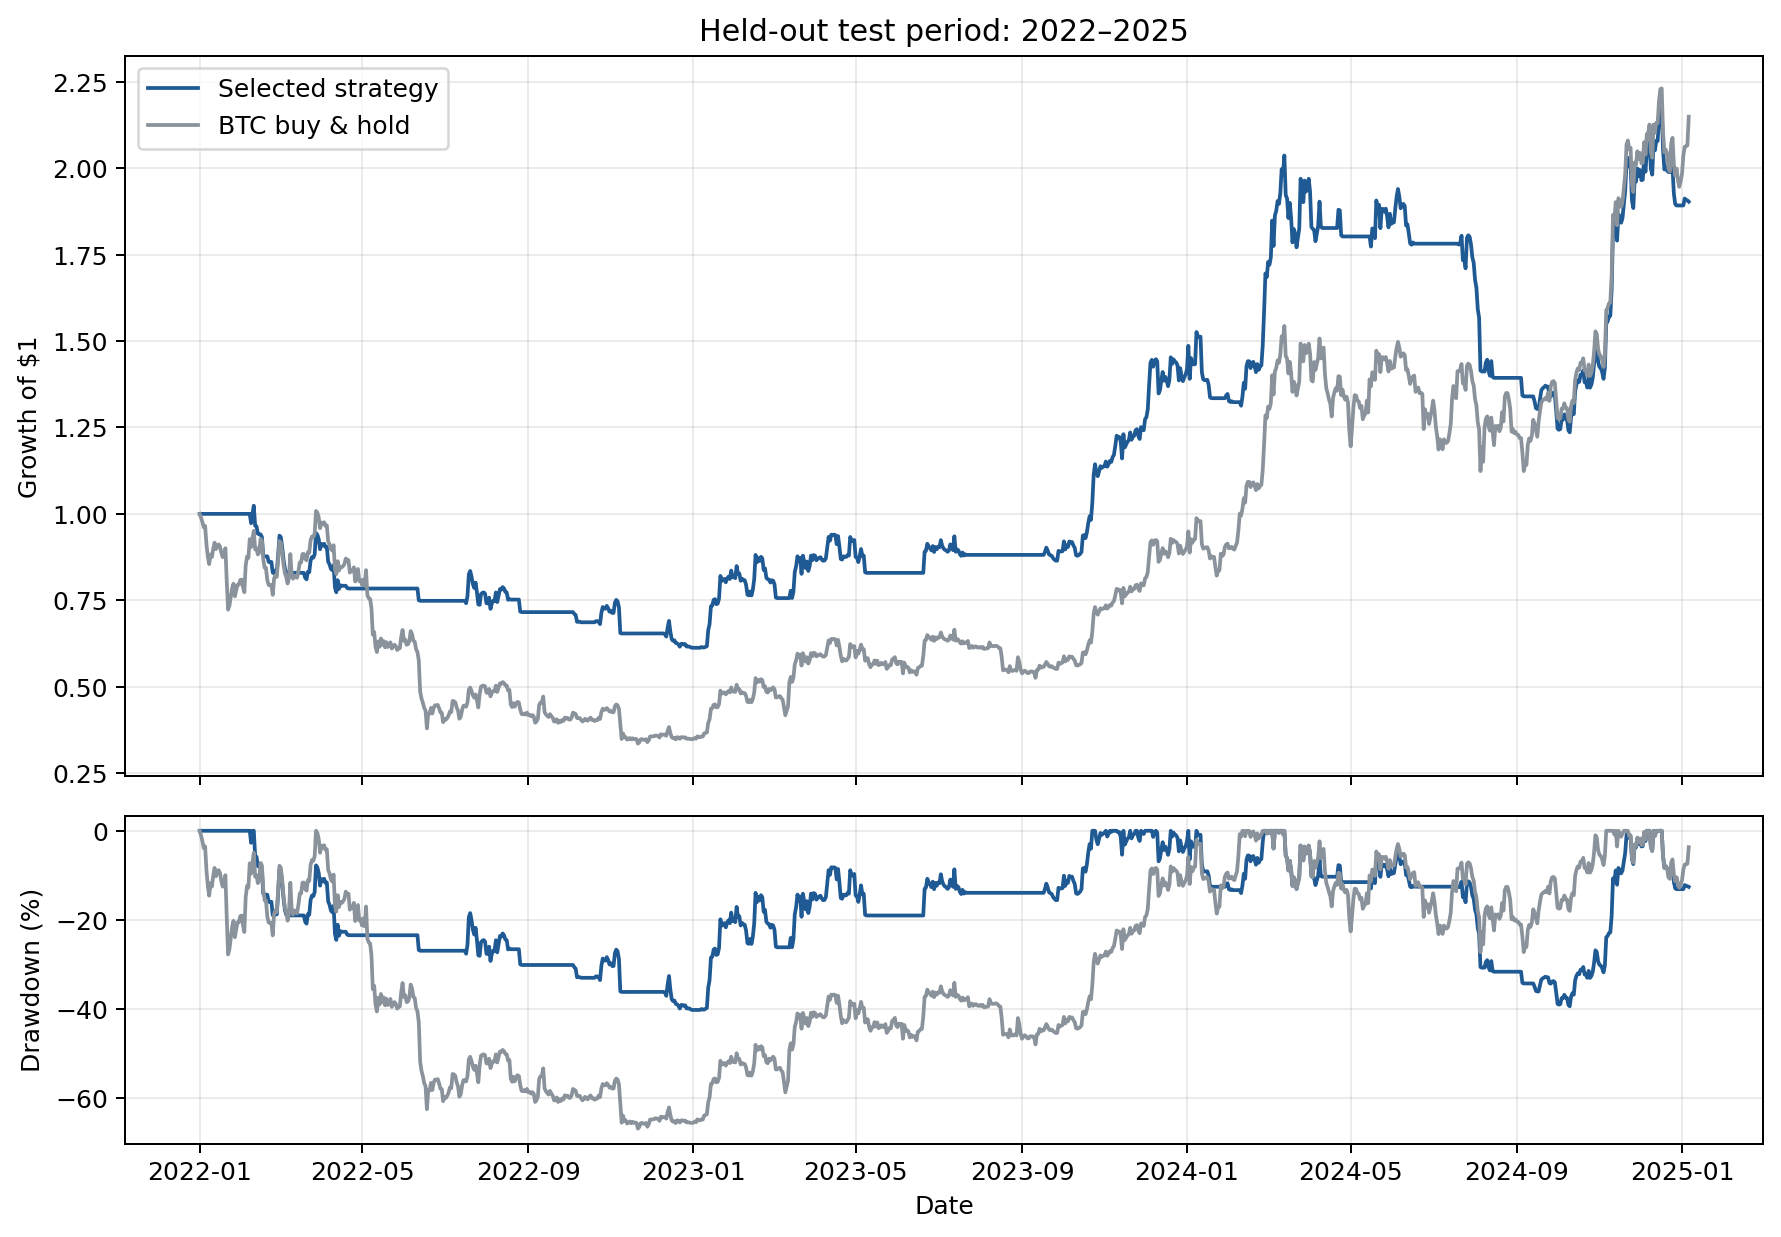

In [15]:
# Backtest curves

test_curves = curves[curves["period"] == "test"]
strategy = test_curves["selected_cum"] / test_curves["selected_cum"].iloc[0]
benchmark = test_curves["buy_hold_cum"] / test_curves["buy_hold_cum"].iloc[0]
strategy_dd = strategy / strategy.cummax() - 1.0
benchmark_dd = benchmark / benchmark.cummax() - 1.0

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1]},
)
axes[0].plot(test_curves.index, strategy, color=BLUE, label="Selected strategy")
axes[0].plot(test_curves.index, benchmark, color=GRAY, label="BTC buy & hold")
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Held-out test period: 2022–2025")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.25)
axes[1].plot(test_curves.index, strategy_dd * 100, color=BLUE)
axes[1].plot(test_curves.index, benchmark_dd * 100, color=GRAY)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.25)
save_and_show(fig, "backtest_test_period.png")


In [16]:
# Conclusion

print("The final selected rule is a 30-day long-only BTC momentum strategy.")
print("It was profitable in the held-out test period and reduced volatility and drawdown versus BTC buy-and-hold.")
print("It did not beat BTC on total return, and the positive alpha estimate was not statistically significant.")


The final selected rule is a 30-day long-only BTC momentum strategy.
It was profitable in the held-out test period and reduced volatility and drawdown versus BTC buy-and-hold.
It did not beat BTC on total return, and the positive alpha estimate was not statistically significant.
